# Movie Audience Prediction — Model Training V3

**Team:** Furkan Fidan | Beyza Nur Selvi | Enes Kocakanat

This notebook presents a full academic machine learning pipeline for predicting Turkish box-office audience numbers (`log_total_audience`). V3 adds **7 new features** on top of V2: 6 LLM-generated features from the Gemini API and 1 deterministic COVID-period feature.

---

| Section | Content |
|---|---|
| 1 | Setup & Data Loading |
| 2 | Preprocessing & Train/Test Split |
| 3 | Model Training (6 models) |
| 4 | Evaluation Metrics (R², MAE, RMSE, MAPE) |
| 5 | Visual Model Comparison + Overfitting Check |
| 6 | Residual Analysis |
| 7 | Feature Importance |
| 8 | Cross-Validation (K-Fold) |
| 9 | Hyperparameter Tuning (GridSearchCV) |

## Section 1: Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
)
from sklearn.metrics import (
    r2_score, mean_absolute_error,
    mean_squared_error, mean_absolute_percentage_error
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# ── Load enriched dataset ──────────────────────────────────────
df = pd.read_csv('../data/processed/llm_enriched_movie_data.csv', encoding='utf-8-sig')

LLM_COLS   = ['director_has_hit', 'star_power', 'budget_tier',
               'is_franchise', 'is_adaptation', 'has_awards']
COVID_COLS = ['is_covid_period']
NEW_COLS   = LLM_COLS + COVID_COLS

print(f'Shape          : {df.shape}')
print(f'Target range   : {df["log_total_audience"].min():.2f} – {df["log_total_audience"].max():.2f}')
print(f'COVID films    : {int(df["is_covid_period"].sum())} / {len(df)}')
print(f'\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0].to_string() or "None"}')
df.head(10)

Shape          : (1100, 26)
Target range   : 8.47 – 15.82
COVID films    : 46 / 1100

Missing values:
Series([], )


,movie_name,genre,genre_count,is_sequel,is_adaptation,is_franchise,rating,runtime_minutes,has_awards,director_has_hit,...,release_year,release_month,release_week,release_season,holiday_type,holiday_week,competition_index,is_covid_period,total_audience,log_total_audience
0,Düğün Dernek 2: Sünnet,Komedi,1,1,0,1,2,112.0,0,1,...,2015,12,49,Winter,none,0,4,0,6073364,15.619423
1,Hızlı ve Öfkeli 7,Aksiyon,1,1,0,1,2,137.0,1,1,...,2015,4,14,Spring,none,0,5,0,2961089,14.901068
2,Kocan Kadar Konuş,Romantik-Komedi,1,0,1,0,2,108.0,0,1,...,2015,3,12,Spring,none,0,11,0,1930677,14.473381
3,Ali Baba ve 7 Cüceler,Komedi,1,0,0,0,3,114.0,0,1,...,2015,11,46,Fall,none,0,5,0,1828311,14.418903
4,Selam: Bahara Yolculuk,Dram,1,0,0,0,3,120.0,0,0,...,2015,3,11,Spring,none,0,11,0,1683497,14.336384
5,Bana Masal Anlatma,"Komedi, Romantik-Komedi",2,0,0,0,1,103.0,0,1,...,2015,1,2,Winter,none,0,12,0,1576979,14.271022
6,Aşk Sana Benzer,"Dram, Romantik",2,0,0,0,0,115.0,0,0,...,2015,1,4,Winter,none,0,12,0,1406620,14.156700
7,Yenilmezler: Ultron Çağı,"Macera, Aksiyon, 3 Boyutlu",3,0,1,1,2,141.0,0,1,...,2015,5,18,Spring,1_mayis,1,8,0,1284848,14.066151
8,Yapışık Kardeşler,Komedi,1,0,0,0,2,105.0,0,0,...,2015,1,5,Winter,none,0,12,0,1014630,13.830035
9,Niyazi Gül Dörtnala,Komedi,1,0,0,1,1,106.0,0,1,...,2015,5,19,Spring,none,0,8,0,994016,13.809509


In [2]:
print('=== Descriptive Statistics ===')
display(df.describe().round(3))

print('\n=== LLM Feature Value Counts ===')
for col in NEW_COLS:
    print(f'\n{col}:')
    print(df[col].value_counts().sort_index().to_string())

=== Descriptive Statistics ===


,genre_count,is_sequel,is_adaptation,is_franchise,rating,runtime_minutes,has_awards,director_has_hit,star_power,budget_tier,...,distributor_film_count,distributor_domestic_ratio,release_year,release_month,release_week,holiday_week,competition_index,is_covid_period,total_audience,log_total_audience
count,1100.000,1100.000,1100.000,1100.000,1100.000,1100.00,1100.000,1100.000,1100.000,1100.000,...,1100.000,1100.000,1100.000,1100.000,1100.000,1100.000,1100.000,1100.000,1100.000,1100.000
mean,2.135,0.155,0.432,0.437,1.170,108.06,0.167,0.525,1.745,1.741,...,180.127,0.408,2020.000,6.423,26.090,0.143,9.840,0.042,396275.110,11.995
std,1.120,0.362,0.496,0.496,1.425,20.67,0.373,0.500,1.103,1.279,...,77.090,0.271,3.164,3.736,16.173,0.350,5.161,0.200,706375.306,1.391
min,1.000,0.000,0.000,0.000,0.000,65.00,0.000,0.000,0.000,0.000,...,1.000,0.000,2015.000,1.000,1.000,0.000,2.000,0.000,4750.000,8.466
25%,1.000,0.000,0.000,0.000,0.000,93.00,0.000,0.000,1.000,1.000,...,123.000,0.137,2017.000,3.000,10.000,0.000,7.000,0.000,63998.000,11.067
50%,2.000,0.000,0.000,0.000,0.000,106.00,0.000,1.000,2.000,1.000,...,181.000,0.343,2020.000,7.000,27.000,0.000,8.000,0.000,169036.500,12.038
75%,3.000,0.000,1.000,1.000,3.000,119.00,0.000,1.000,3.000,3.000,...,225.000,0.716,2023.000,10.000,41.000,0.000,12.000,0.000,414307.000,12.934
max,6.000,1.000,1.000,1.000,4.000,206.00,1.000,1.000,3.000,4.000,...,271.000,1.000,2025.000,12.000,53.000,1.000,27.000,1.000,7437050.000,15.822



=== LLM Feature Value Counts ===

director_has_hit:
director_has_hit
0    523
1    577

star_power:
star_power
0    211
1    211
2    325
3    353

budget_tier:
budget_tier
0    182
1    391
2    198
3    188
4    141

is_franchise:
is_franchise
0    619
1    481

is_adaptation:
is_adaptation
0    625
1    475

has_awards:
has_awards
0    916
1    184

is_covid_period:
is_covid_period
0    1054
1      46


## Section 2: Preprocessing & Train/Test Split

**Steps:**
1. Multi-hot encoding for `genre` (one binary column per tag)
2. Distributor target encoding — computed on **training data only** to prevent data leakage
3. One-hot encoding for `release_season` and `holiday_type`
4. 80/20 train/test split with shuffle
5. `StandardScaler` for linear models; raw features for tree models

In [3]:
# ── 1. Genre multi-hot encoding ───────────────────────────────
all_genres = set()
for g in df['genre']:
    for tag in str(g).split(','):
        t = tag.strip()
        if t and t != 'Bilinmiyor':
            all_genres.add(t)
all_genres = sorted(all_genres)

def make_col(tag):
    return 'is_genre_' + tag.lower().replace(' ', '_').replace('-', '_')

for genre in all_genres:
    col = make_col(genre)
    df[col] = df['genre'].apply(
        lambda x: 1 if genre in [t.strip() for t in str(x).split(',')] else 0
    )

genre_cols = [c for c in df.columns if c.startswith('is_genre_')]
print(f'Genre tags: {len(all_genres)}  |  Binary columns: {len(genre_cols)}')

# ── 2. Prepare feature matrix ─────────────────────────────────
DROP_COLS = ['movie_name', 'genre', 'holiday_week', 'total_audience']
X = df.drop(['log_total_audience'] + DROP_COLS, axis=1)
y = df['log_total_audience']

# ── 3. Train / Test split (80/20, shuffled) ───────────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
X_train_raw, X_test_raw = X_train_raw.copy(), X_test_raw.copy()

print(f'Train : {len(X_train_raw)} films  |  Test : {len(X_test_raw)} films')

# ── 4. Distributor target encoding (train-only, leakage-free) ─
dist_means = y_train.groupby(X_train_raw['distributor']).mean()
dist_stds  = y_train.groupby(X_train_raw['distributor']).std().fillna(0)
fallback_mean = float(y_train.mean())
fallback_std  = float(dist_stds.mean())

for split in [X_train_raw, X_test_raw]:
    split['distributor_power'] = split['distributor'].map(dist_means).fillna(fallback_mean)
    split['distributor_std']   = split['distributor'].map(dist_stds).fillna(fallback_std)

X_train_raw = X_train_raw.drop('distributor', axis=1)
X_test_raw  = X_test_raw.drop('distributor', axis=1)

# ── 5. One-hot encoding ───────────────────────────────────────
OHE_COLS    = ['release_season', 'holiday_type']
X_train     = pd.get_dummies(X_train_raw, columns=OHE_COLS, drop_first=False)
X_test      = pd.get_dummies(X_test_raw,  columns=OHE_COLS, drop_first=False)
X_test      = X_test.reindex(columns=X_train.columns, fill_value=0)

# ── 6. StandardScaler (linear models) ────────────────────────
scaler        = StandardScaler()
X_train_sc    = scaler.fit_transform(X_train)
X_test_sc     = scaler.transform(X_test)

feature_names = X_train.columns.tolist()

print(f'\nTotal features (after OHE): {len(feature_names)}')
print(f'  New V3 features: {[c for c in NEW_COLS if c in feature_names]}')
print(f'Scaling applied   : StandardScaler (mean=0, std=1) for linear models')

Genre tags: 29  |  Binary columns: 29
Train : 880 films  |  Test : 220 films

Total features (after OHE): 63
  New V3 features: ['director_has_hit', 'star_power', 'budget_tier', 'is_franchise', 'is_adaptation', 'has_awards', 'is_covid_period']
Scaling applied   : StandardScaler (mean=0, std=1) for linear models


## Section 3: Model Training

Six models are trained:

| Model | Type | Input |
|---|---|---|
| Linear Regression | Baseline linear | Scaled |
| Ridge | Regularized linear (L2) | Scaled |
| Lasso | Regularized linear (L1) | Scaled |
| Decision Tree | Non-linear | Raw |
| Random Forest | Ensemble (bagging) | Raw |
| Gradient Boosting | Ensemble (boosting) | Raw |

In [4]:
# Model definitions
LINEAR_MODELS = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(alpha=1.0),
    'Lasso':             Lasso(alpha=0.01, max_iter=5000),
}
TREE_MODELS = {
    'Decision Tree':    DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest':    RandomForestRegressor(n_estimators=300, max_depth=10,
                                              random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300,
                                                    learning_rate=0.05,
                                                    random_state=42),
}
ALL_MODELS = {**LINEAR_MODELS, **TREE_MODELS}
MODEL_ORDER = list(ALL_MODELS.keys())

# ── Train all models ──────────────────────────────────────────
trained   = {}
results   = {}
y_preds   = {}

def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    pred_train = model.predict(X_tr)
    pred_test  = model.predict(X_te)

    # Metrics on original scale (exp of log predictions)
    y_te_orig  = np.exp(y_te.values)
    pred_orig  = np.exp(pred_test)

    return {
        'r2_train': r2_score(y_tr, pred_train),
        'r2_test' : r2_score(y_te, pred_test),
        'mae'     : mean_absolute_error(y_te, pred_test),
        'rmse'    : np.sqrt(mean_squared_error(y_te, pred_test)),
        'mape'    : mean_absolute_percentage_error(y_te_orig, pred_orig),
    }, pred_test

print('Training models...')
for name, model in LINEAR_MODELS.items():
    results[name], y_preds[name] = evaluate(
        name, model, X_train_sc, X_test_sc, y_train, y_test
    )
    trained[name] = model
    print(f'  {name:22s} R²={results[name]["r2_test"]:.4f}')

for name, model in TREE_MODELS.items():
    results[name], y_preds[name] = evaluate(
        name, model, X_train.values, X_test.values, y_train, y_test
    )
    trained[name] = model
    print(f'  {name:22s} R²={results[name]["r2_test"]:.4f}')

best_model_name = max(results, key=lambda k: results[k]['r2_test'])
print(f'\nBest model: {best_model_name} (R²={results[best_model_name]["r2_test"]:.4f})')

Training models...
  Linear Regression      R²=0.6098
  Ridge                  R²=0.6096
  Lasso                  R²=0.6132
  Decision Tree          R²=0.2567
  Random Forest          R²=0.6209
  Gradient Boosting      R²=0.6613

Best model: Gradient Boosting (R²=0.6613)


## Section 4: Evaluation Metrics

Four metrics are reported for each model:

- **R²** — proportion of variance explained (higher = better, max 1.0)
- **MAE** — mean absolute error on log scale
- **RMSE** — root mean squared error; penalizes large errors more than MAE
- **MAPE** — mean absolute percentage error on the **original audience scale** (intuitive for business)

In [11]:
metrics_df = pd.DataFrame({
    name: {
        'R² (test)':      round(v['r2_test'],  4),
        'R² (train)':     round(v['r2_train'], 4),
        'MAE (log)':      round(v['mae'],       4),
        'RMSE (log)':     round(v['rmse'],      4),
        'MAPE (orig %)':  round(v['mape']*100,  2),
    }
    for name, v in results.items()
}).T

metrics_df = metrics_df.loc[MODEL_ORDER]

# Highlight best value in each metric column
def highlight_best(s):
    if 'R²' in s.name:
        best = s.max()
    else:
        best = s.min()
    return ['background-color: #a800cf; font-weight: bold'
            if v == best else '' for v in s]

print('=== Model Performance Summary ===')
display(metrics_df.style.apply(highlight_best))

=== Model Performance Summary ===


,R² (test),R² (train),MAE (log),RMSE (log),MAPE (orig %)
Linear Regression,0.609800,0.634000,0.666600,0.833900,87.450000
Ridge,0.609600,0.633900,0.666900,0.834000,87.470000
Lasso,0.613200,0.629600,0.665400,0.830200,86.980000
Decision Tree,0.256700,0.838600,0.871900,1.150900,224.450000
Random Forest,0.620900,0.907900,0.658900,0.821900,76.370000
Gradient Boosting,0.661300,0.825900,0.620800,0.776900,76.350000


## Section 5: Visual Model Comparison & Overfitting Check

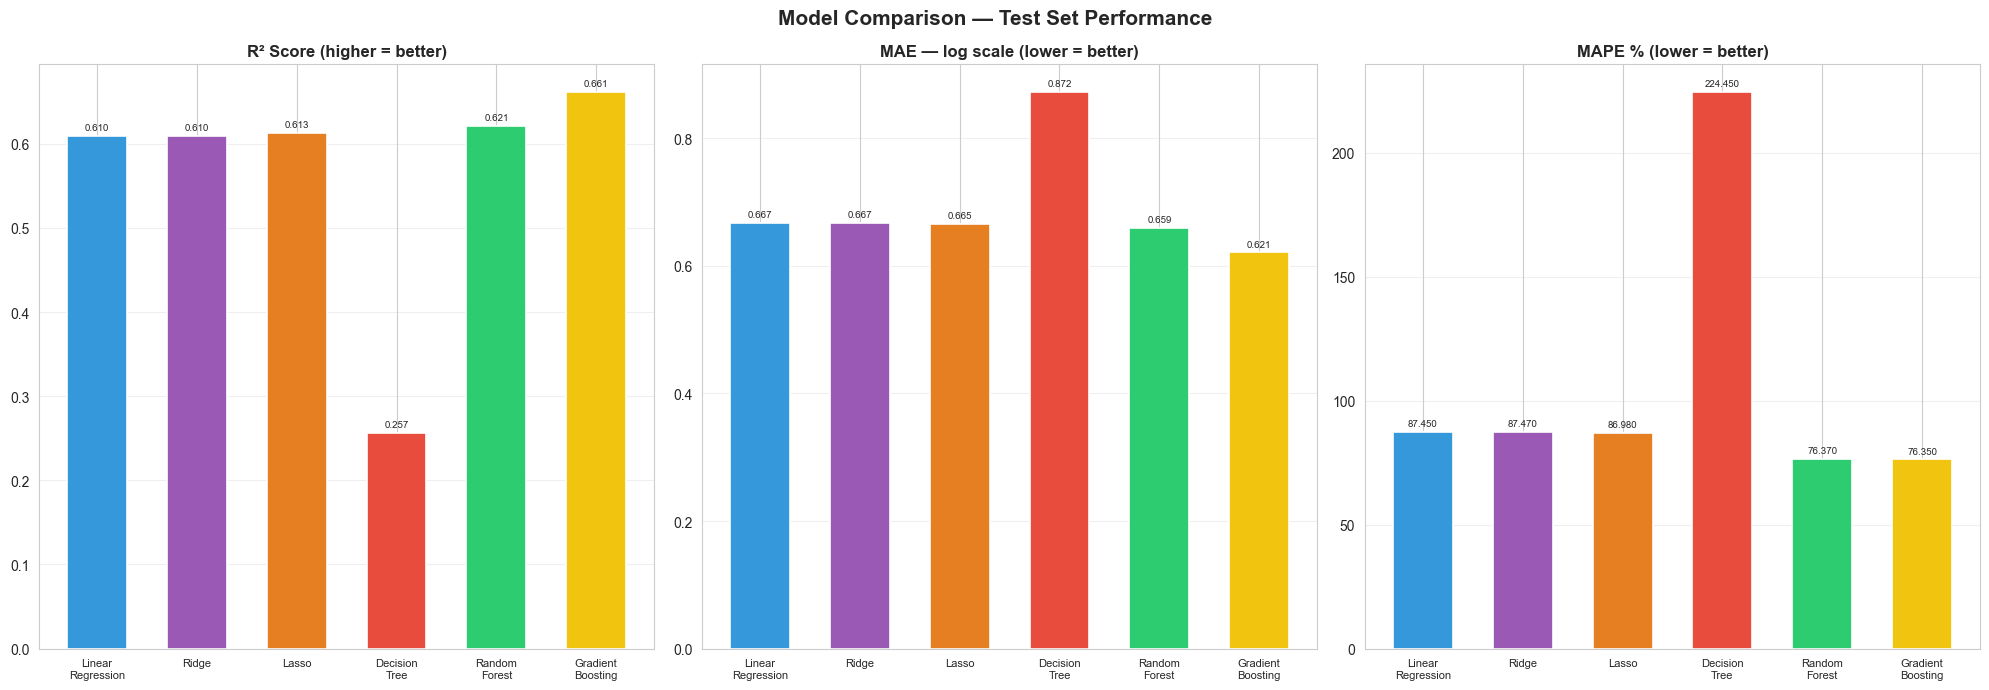

In [6]:
colors = ['#3498db', '#9b59b6', '#e67e22', '#e74c3c', '#2ecc71', '#1abc9c']

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Model Comparison — Test Set Performance', fontsize=15, fontweight='bold')

x = np.arange(len(MODEL_ORDER))
w = 0.6

for ax, metric, label, best_fn in [
    (axes[0], 'R² (test)',     'R² Score (higher = better)',     max),
    (axes[1], 'MAE (log)',     'MAE — log scale (lower = better)', min),
    (axes[2], 'MAPE (orig %)', 'MAPE % (lower = better)',         min),
]:
    vals      = [metrics_df.loc[m, metric] for m in MODEL_ORDER]
    best_val  = best_fn(vals)
    bar_cols  = ['#f1c40f' if v == best_val else c
                 for v, c in zip(vals, colors)]
    bars = ax.bar(x, vals, color=bar_cols, edgecolor='white',
                  linewidth=1.2, width=w)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [m.replace(' ', '\n') for m in MODEL_ORDER], fontsize=8
    )
    ax.set_title(label, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + ax.get_ylim()[1]*0.01,
                f'{h:.3f}', ha='center', fontsize=7)

plt.tight_layout()
plt.show()

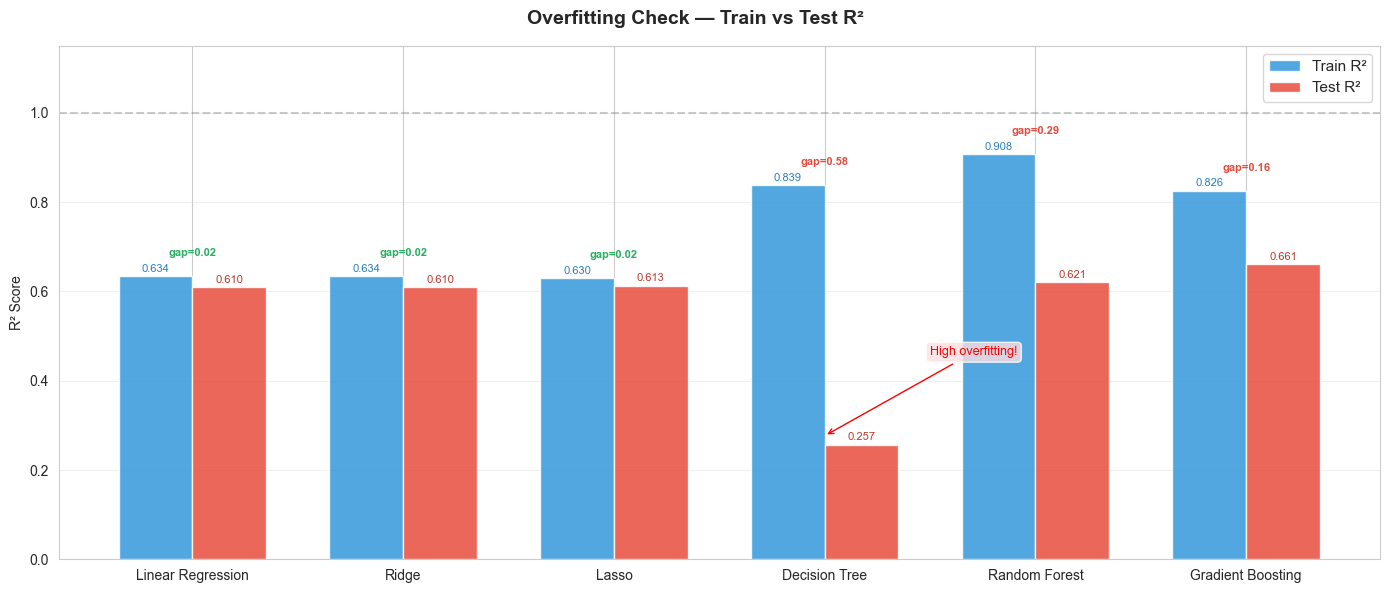


Train-Test R² Gap (higher gap = more overfitting):
  Decision Tree          gap = 0.5819 ← OVERFITTING
  Random Forest          gap = 0.2870 ← OVERFITTING
  Gradient Boosting      gap = 0.1646 ← OVERFITTING
  Ridge                  gap = 0.0243
  Linear Regression      gap = 0.0242
  Lasso                  gap = 0.0164


In [7]:
# ── Overfitting Check: Train R² vs Test R² ────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Overfitting Check — Train vs Test R²', fontsize=14, fontweight='bold')

train_r2s = [metrics_df.loc[m, 'R² (train)'] for m in MODEL_ORDER]
test_r2s  = [metrics_df.loc[m, 'R² (test)']  for m in MODEL_ORDER]
gaps      = [tr - te for tr, te in zip(train_r2s, test_r2s)]

xpos = np.arange(len(MODEL_ORDER))
w2   = 0.35

bars1 = ax.bar(xpos - w2/2, train_r2s, width=w2, label='Train R²',
               color='#3498db', alpha=0.85, edgecolor='white')
bars2 = ax.bar(xpos + w2/2, test_r2s,  width=w2, label='Test R²',
               color='#e74c3c', alpha=0.85, edgecolor='white')

for i, (b1, b2, gap) in enumerate(zip(bars1, bars2, gaps)):
    ax.text(b1.get_x() + b1.get_width()/2, b1.get_height() + 0.01,
            f'{b1.get_height():.3f}', ha='center', fontsize=8, color='#2980b9')
    ax.text(b2.get_x() + b2.get_width()/2, b2.get_height() + 0.01,
            f'{b2.get_height():.3f}', ha='center', fontsize=8, color='#c0392b')
    color = '#e74c3c' if gap > 0.15 else '#27ae60'
    ax.text(i, max(train_r2s[i], test_r2s[i]) + 0.045,
            f'gap={gap:.2f}', ha='center', fontsize=8,
            color=color, fontweight='bold')

ax.set_xticks(xpos)
ax.set_xticklabels(MODEL_ORDER, fontsize=10)
ax.set_ylabel('R² Score')
ax.set_ylim(0, 1.15)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.4)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Overfitting annotation
worst_gap_idx = gaps.index(max(gaps))
ax.annotate('High overfitting!',
            xy=(worst_gap_idx, test_r2s[worst_gap_idx] + 0.02),
            xytext=(worst_gap_idx + 0.5, test_r2s[worst_gap_idx] + 0.2),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=9, color='red',
            bbox=dict(boxstyle='round', facecolor='#ffe0e0', alpha=0.8))

plt.tight_layout()
plt.show()

print('\nTrain-Test R² Gap (higher gap = more overfitting):')
for m, g in sorted(zip(MODEL_ORDER, gaps), key=lambda x: -x[1]):
    flag = ' ← OVERFITTING' if g > 0.15 else ''
    print(f'  {m:22s} gap = {g:.4f}{flag}')

## Section 6: Residual Analysis

A well-fitted model should have residuals that are:
- **Randomly scattered** around zero (no systematic pattern)
- **Normally distributed** (histogram should be bell-shaped)
- **Homoscedastic** (equal variance across predicted values)

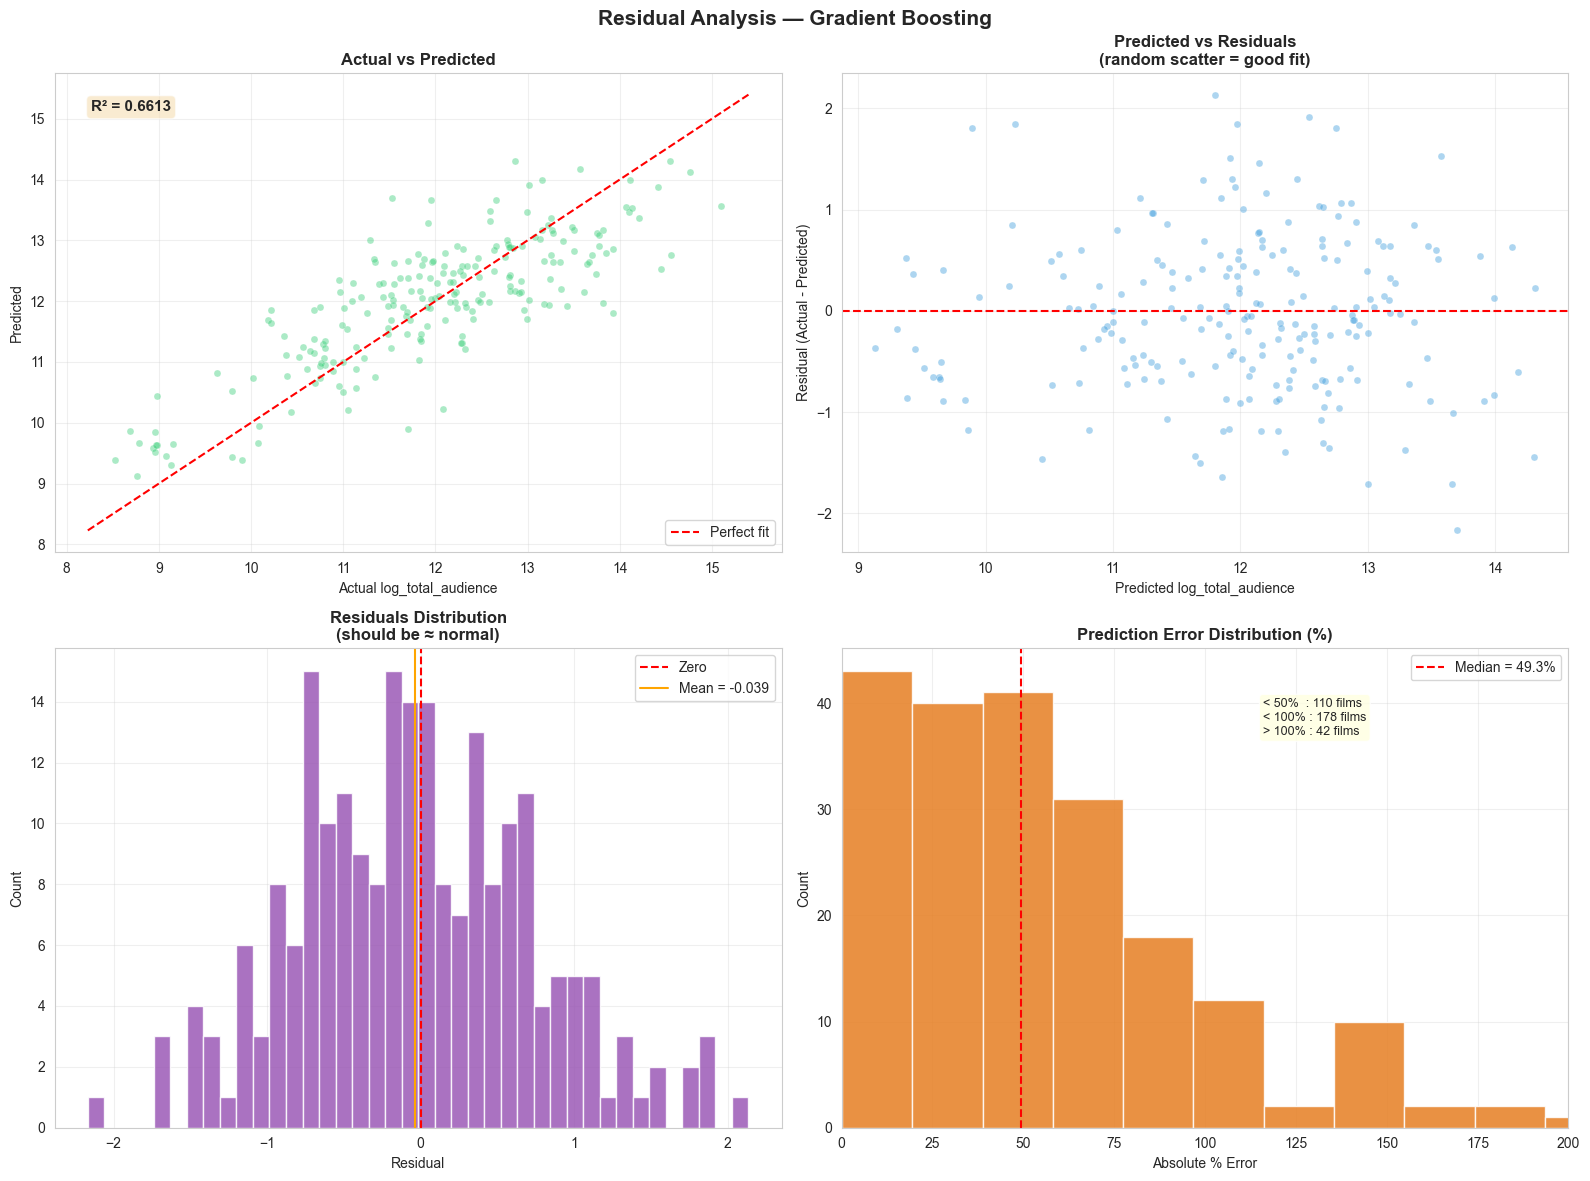

Residual mean  : -0.0388  (close to 0 = unbiased)
Residual std   : 0.7759
Median % error : 49.3%


In [8]:
best_pred  = y_preds[best_model_name]
residuals  = y_test.values - best_pred
errors_pct = (abs(np.exp(y_test.values) - np.exp(best_pred))
              / np.exp(y_test.values) * 100)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Residual Analysis — {best_model_name}',
             fontsize=15, fontweight='bold')

# ── 1. Actual vs Predicted ────────────────────────────────────
ax = axes[0, 0]
ax.scatter(y_test, best_pred, alpha=0.4, color='#2ecc71',
           s=25, edgecolors='white', linewidth=0.3)
lims = [y_test.min() - 0.3, y_test.max() + 0.3]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual log_total_audience')
ax.set_ylabel('Predicted')
ax.set_title('Actual vs Predicted', fontweight='bold')
ax.text(0.05, 0.92, f'R² = {results[best_model_name]["r2_test"]:.4f}',
        transform=ax.transAxes, fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))
ax.legend(); ax.grid(alpha=0.3)

# ── 2. Predicted vs Residuals (pattern detection) ────────────
ax = axes[0, 1]
ax.scatter(best_pred, residuals, alpha=0.4, color='#3498db',
           s=25, edgecolors='white', linewidth=0.3)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Predicted log_total_audience')
ax.set_ylabel('Residual (Actual - Predicted)')
ax.set_title('Predicted vs Residuals\n(random scatter = good fit)', fontweight='bold')
ax.grid(alpha=0.3)

# ── 3. Residuals histogram ────────────────────────────────────
ax = axes[1, 0]
ax.hist(residuals, bins=40, color='#9b59b6', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
ax.axvline(residuals.mean(), color='orange', linestyle='-', linewidth=1.5,
           label=f'Mean = {residuals.mean():.3f}')
ax.set_xlabel('Residual')
ax.set_ylabel('Count')
ax.set_title('Residuals Distribution\n(should be ≈ normal)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# ── 4. % Error distribution ───────────────────────────────────
ax = axes[1, 1]
ax.hist(errors_pct, bins=40, color='#e67e22', edgecolor='white', alpha=0.85)
med = np.median(errors_pct)
ax.axvline(med, color='red', linestyle='--', linewidth=1.5,
           label=f'Median = {med:.1f}%')
ax.set_xlim(0, 200)
ax.set_xlabel('Absolute % Error')
ax.set_ylabel('Count')
ax.set_title('Prediction Error Distribution (%)', fontweight='bold')
ax.text(0.58, 0.82,
        f'< 50%  : {(errors_pct < 50).sum()} films\n'
        f'< 100% : {(errors_pct < 100).sum()} films\n'
        f'> 100% : {(errors_pct >= 100).sum()} films',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Residual mean  : {residuals.mean():.4f}  (close to 0 = unbiased)')
print(f'Residual std   : {residuals.std():.4f}')
print(f'Median % error : {med:.1f}%')

## Section 7: Feature Importance

Feature importance scores from the Random Forest model (mean decrease in impurity).
Colors indicate feature origin: **red = LLM**, **orange = COVID**, green = distributor, blue = genre.

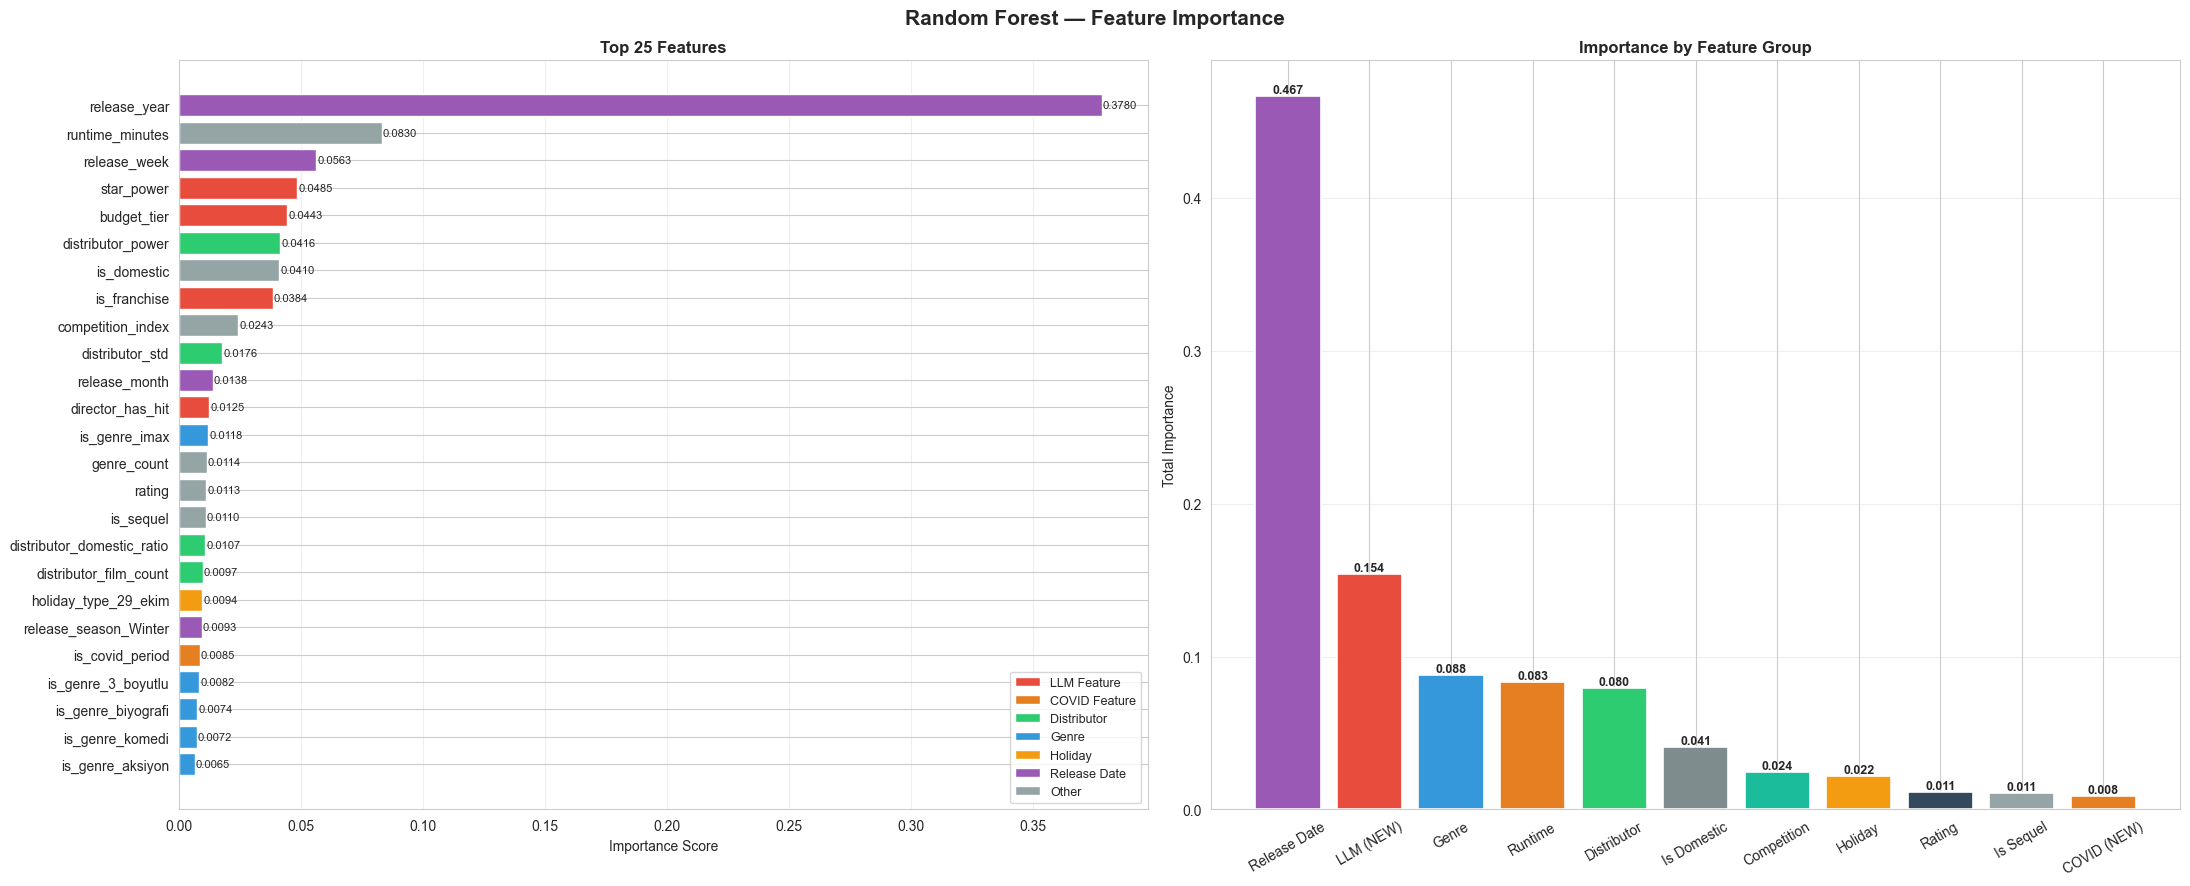

In [9]:
rf_model  = trained['Random Forest']
feat_imp  = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

top_n    = 25
top_feat = feat_imp.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle('Random Forest — Feature Importance', fontsize=15, fontweight='bold')

# ── 1. Top N features ─────────────────────────────────────────
ax = axes[0]
bar_colors = []
for f in top_feat.index:
    if f in LLM_COLS:             bar_colors.append('#e74c3c')
    elif f in COVID_COLS:         bar_colors.append('#e67e22')
    elif 'distributor' in f:      bar_colors.append('#2ecc71')
    elif f.startswith('is_genre'): bar_colors.append('#3498db')
    elif 'holiday' in f:          bar_colors.append('#f39c12')
    elif 'release' in f:          bar_colors.append('#9b59b6')
    else:                         bar_colors.append('#95a5a6')

bars = ax.barh(top_feat.index[::-1], top_feat.values[::-1],
               color=bar_colors[::-1])
ax.set_title(f'Top {top_n} Features', fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
for bar in bars:
    ax.text(bar.get_width() + 0.0005,
            bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=8)

legend_elements = [
    mpatches.Patch(facecolor='#e74c3c', label='LLM Feature'),
    mpatches.Patch(facecolor='#e67e22', label='COVID Feature'),
    mpatches.Patch(facecolor='#2ecc71', label='Distributor'),
    mpatches.Patch(facecolor='#3498db', label='Genre'),
    mpatches.Patch(facecolor='#f39c12', label='Holiday'),
    mpatches.Patch(facecolor='#9b59b6', label='Release Date'),
    mpatches.Patch(facecolor='#95a5a6', label='Other'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

# ── 2. Grouped importance ─────────────────────────────────────
ax = axes[1]
groups = {
    'Distributor':  feat_imp[[f for f in feat_imp.index if 'distributor' in f]].sum(),
    'Genre':        feat_imp[[f for f in feat_imp.index if f.startswith('is_genre')]].sum(),
    'LLM (NEW)':    feat_imp[[f for f in feat_imp.index if f in LLM_COLS]].sum(),
    'COVID (NEW)':  feat_imp[[f for f in feat_imp.index if f in COVID_COLS]].sum(),
    'Holiday':      feat_imp[[f for f in feat_imp.index if 'holiday' in f]].sum(),
    'Release Date': feat_imp[[f for f in feat_imp.index if 'release' in f]].sum(),
    'Competition':  feat_imp[[f for f in feat_imp.index if 'competition' in f]].sum(),
    'Runtime':      feat_imp[[f for f in feat_imp.index if 'runtime' in f]].sum(),
    'Rating':       feat_imp[[f for f in feat_imp.index if f == 'rating']].sum(),
    'Is Domestic':  feat_imp[[f for f in feat_imp.index if f == 'is_domestic']].sum(),
    'Is Sequel':    feat_imp[[f for f in feat_imp.index if 'sequel' in f]].sum(),
}
gs = pd.Series(groups).sort_values(ascending=False)
gcols = {
    'LLM (NEW)': '#e74c3c', 'COVID (NEW)': '#e67e22',
    'Distributor': '#2ecc71', 'Genre': '#3498db',
    'Holiday': '#f39c12', 'Release Date': '#9b59b6',
    'Competition': '#1abc9c', 'Runtime': '#e67e22',
    'Rating': '#34495e', 'Is Domestic': '#7f8c8d', 'Is Sequel': '#95a5a6',
}
bc = [gcols.get(g, '#bdc3c7') for g in gs.index]
bars2 = ax.bar(gs.index, gs.values, color=bc, edgecolor='white', linewidth=1.2)
ax.set_title('Importance by Feature Group', fontweight='bold')
ax.set_ylabel('Total Importance')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Section 8: Cross-Validation (5-Fold K-Fold)

K-Fold CV splits the training data into 5 parts. Each part acts as a validation set once. This proves model **stability** — a model that scores well only on one particular test split is unreliable.

In [12]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Reconstruct fully preprocessed matrices by stacking the already-encoded
# train + test splits. We cannot reuse raw X because it still contains the
# string 'distributor' column that StandardScaler cannot accept.
X_full_tree = np.vstack([X_train.values, X_test.values])
y_full      = np.concatenate([y_train.values, y_test.values])

scaler_cv   = StandardScaler()
X_full_lin  = scaler_cv.fit_transform(X_full_tree)

cv_results = {}
print('Running 5-Fold Cross-Validation...')
for name, model in ALL_MODELS.items():
    X_cv = X_full_lin if name in LINEAR_MODELS else X_full_tree
    scores = cross_val_score(model, X_cv, y_full, cv=kf,
                             scoring='r2', n_jobs=-1)
    cv_results[name] = scores
    print(f'  {name:22s} CV R²: {scores.mean():.4f} ± {scores.std():.4f}')

# ── CV Results table ──────────────────────────────────────────
cv_df = pd.DataFrame({
    name: {
        'CV Mean R²': round(scores.mean(), 4),
        'CV Std R²':  round(scores.std(),  4),
        'Test R²':    round(results[name]['r2_test'], 4),
        'Stability':  'Stable' if scores.std() < 0.05 else 'Unstable',
    }
    for name, scores in cv_results.items()
}).T.loc[MODEL_ORDER]

print('\n=== Cross-Validation Summary ===')
display(cv_df)

Running 5-Fold Cross-Validation...
  Linear Regression      CV R²: 0.5840 ± 0.0196
  Ridge                  CV R²: 0.5842 ± 0.0198
  Lasso                  CV R²: 0.5912 ± 0.0175
  Decision Tree          CV R²: 0.3588 ± 0.0474
  Random Forest          CV R²: 0.6086 ± 0.0377
  Gradient Boosting      CV R²: 0.6377 ± 0.0166

=== Cross-Validation Summary ===


,CV Mean R²,CV Std R²,Test R²,Stability
Linear Regression,0.584,0.0196,0.6098,Stable
Ridge,0.5842,0.0198,0.6096,Stable
Lasso,0.5912,0.0175,0.6132,Stable
Decision Tree,0.3588,0.0474,0.2567,Stable
Random Forest,0.6086,0.0377,0.6209,Stable
Gradient Boosting,0.6377,0.0166,0.6613,Stable


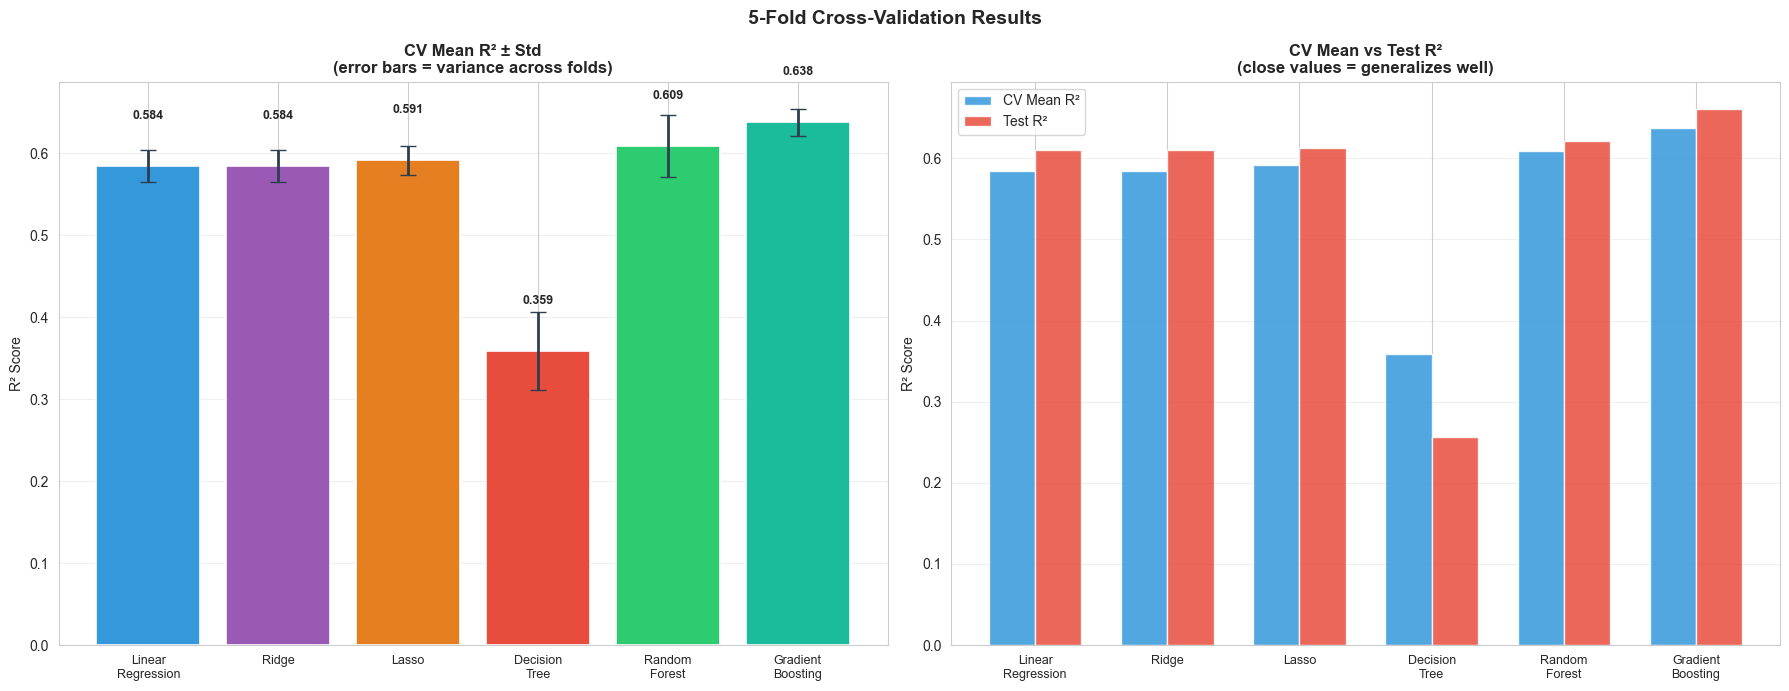

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('5-Fold Cross-Validation Results', fontsize=14, fontweight='bold')

# ── 1. CV mean ± std bar chart ────────────────────────────────
ax = axes[0]
means = [cv_results[m].mean() for m in MODEL_ORDER]
stds  = [cv_results[m].std()  for m in MODEL_ORDER]
xpos  = np.arange(len(MODEL_ORDER))

bars = ax.bar(xpos, means, yerr=stds, capsize=6,
              color=colors, edgecolor='white', linewidth=1.2,
              error_kw={'ecolor': '#2c3e50', 'linewidth': 2})
ax.set_xticks(xpos)
ax.set_xticklabels([m.replace(' ', '\n') for m in MODEL_ORDER], fontsize=9)
ax.set_ylabel('R² Score')
ax.set_title('CV Mean R² ± Std\n(error bars = variance across folds)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(stds) + 0.01,
            f'{mean:.3f}', ha='center', fontsize=9, fontweight='bold')

# ── 2. CV score vs Test score comparison ─────────────────────
ax = axes[1]
test_r2s  = [results[m]['r2_test'] for m in MODEL_ORDER]
cv_means  = [cv_results[m].mean()  for m in MODEL_ORDER]
w2 = 0.35

ax.bar(xpos - w2/2, cv_means,  width=w2, label='CV Mean R²',
       color='#3498db', alpha=0.85, edgecolor='white')
ax.bar(xpos + w2/2, test_r2s, width=w2, label='Test R²',
       color='#e74c3c', alpha=0.85, edgecolor='white')
ax.set_xticks(xpos)
ax.set_xticklabels([m.replace(' ', '\n') for m in MODEL_ORDER], fontsize=9)
ax.set_ylabel('R² Score')
ax.set_title('CV Mean vs Test R²\n(close values = generalizes well)', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Section 9: Hyperparameter Tuning (GridSearchCV)

Grid search exhaustively tests combinations of hyperparameters using cross-validation to find the optimal configuration for the best-performing model (Random Forest).

In [14]:
param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [8, 10, 12],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2],
}

n_combinations = 1
for v in param_grid.values():
    n_combinations *= len(v)
print(f'Grid size: {n_combinations} combinations × 5 folds = {n_combinations * 5} fits')
print('Running GridSearchCV (this may take a few minutes)...')

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0,
    refit=True,
)
grid_search.fit(X_train.values, y_train)

best_params = grid_search.best_params_
best_cv_r2  = grid_search.best_score_

print(f'\nBest parameters  : {best_params}')
print(f'Best CV R²       : {best_cv_r2:.4f}')

# Evaluate tuned model on test set
tuned_rf   = grid_search.best_estimator_
pred_tuned = tuned_rf.predict(X_test.values)

r2_tuned   = r2_score(y_test, pred_tuned)
mae_tuned  = mean_absolute_error(y_test, pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, pred_tuned))
mape_tuned = mean_absolute_percentage_error(
    np.exp(y_test.values), np.exp(pred_tuned)
)

r2_base    = results['Random Forest']['r2_test']

print(f'\n{"Metric":<15} {"Baseline RF":>14} {"Tuned RF":>14} {"Delta":>10}')
print('-' * 55)
print(f'{"R² (test)":<15} {r2_base:>14.4f} {r2_tuned:>14.4f} {r2_tuned-r2_base:>+10.4f}')
print(f'{"MAE":<15} {results["Random Forest"]["mae"]:>14.4f} {mae_tuned:>14.4f} {mae_tuned-results["Random Forest"]["mae"]:>+10.4f}')
print(f'{"RMSE":<15} {results["Random Forest"]["rmse"]:>14.4f} {rmse_tuned:>14.4f} {rmse_tuned-results["Random Forest"]["rmse"]:>+10.4f}')
print(f'{"MAPE %":<15} {results["Random Forest"]["mape"]*100:>14.2f} {mape_tuned*100:>14.2f} {(mape_tuned-results["Random Forest"]["mape"])*100:>+10.2f}')

Grid size: 36 combinations × 5 folds = 180 fits
Running GridSearchCV (this may take a few minutes)...

Best parameters  : {'max_depth': 12, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best CV R²       : 0.5850

Metric             Baseline RF       Tuned RF      Delta
-------------------------------------------------------
R² (test)               0.6209         0.6246    +0.0037
MAE                     0.6589         0.6564    -0.0025
RMSE                    0.8219         0.8179    -0.0040
MAPE %                   76.37          75.58      -0.79


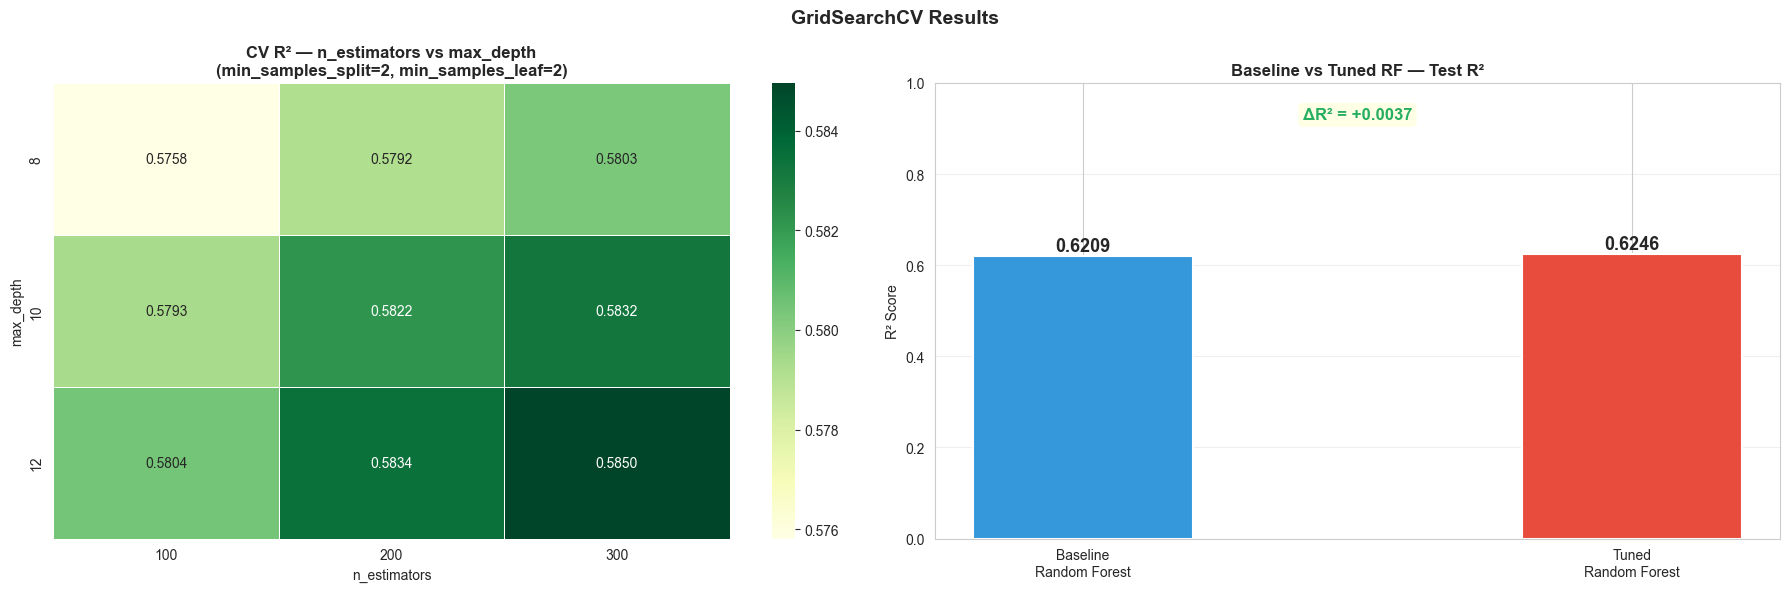

In [15]:
# ── GridSearch heatmap: n_estimators vs max_depth ────────────
cv_res = pd.DataFrame(grid_search.cv_results_)

# Best min_samples_split and min_samples_leaf
best_mss  = best_params['min_samples_split']
best_msl  = best_params['min_samples_leaf']

subset = cv_res[
    (cv_res['param_min_samples_split'] == best_mss) &
    (cv_res['param_min_samples_leaf'] == best_msl)
].copy()

pivot = subset.pivot_table(
    index='param_max_depth',
    columns='param_n_estimators',
    values='mean_test_score'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('GridSearchCV Results', fontsize=14, fontweight='bold')

# Heatmap
ax = axes[0]
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGn',
            ax=ax, linewidths=0.5, linecolor='white',
            annot_kws={'size': 10})
ax.set_title(f'CV R² — n_estimators vs max_depth\n'
             f'(min_samples_split={best_mss}, min_samples_leaf={best_msl})',
             fontweight='bold')
ax.set_xlabel('n_estimators')
ax.set_ylabel('max_depth')

# Baseline vs Tuned comparison
ax = axes[1]
model_labels  = ['Baseline\nRandom Forest', 'Tuned\nRandom Forest']
r2_vals       = [r2_base, r2_tuned]
bar_colors_bt = ['#3498db', '#e74c3c']
bars = ax.bar(model_labels, r2_vals, color=bar_colors_bt,
              width=0.4, edgecolor='white', linewidth=1.5)
ax.set_title('Baseline vs Tuned RF — Test R²', fontweight='bold')
ax.set_ylabel('R² Score')
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', fontsize=13, fontweight='bold')
delta = r2_tuned - r2_base
ax.text(0.5, 0.92,
        f'\u0394R\u00b2 = {delta:+.4f}',
        ha='center', transform=ax.transAxes, fontsize=12,
        color='#27ae60' if delta >= 0 else '#e74c3c', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

## Final Summary

In [16]:
print('=' * 60)
print('  MOVIE AUDIENCE PREDICTION — FINAL RESULTS SUMMARY')
print('=' * 60)

print(f'\nDataset        : {len(df)} films (2015–2025, Turkey)')
print(f'Target         : log_total_audience (Turkish box-office)')
print(f'New features   : {len(NEW_COLS)} (6 LLM + 1 COVID)')
print(f'Total features : {len(feature_names)} (after encoding)')
print(f'Train/Test     : 80% / 20%  (random_state=42, shuffled)')

print('\n--- All Models (Test Set) ---')
print(f'{"Model":<22} {"R²":>8} {"MAE":>8} {"RMSE":>8} {"MAPE%":>8}')
print('-' * 56)
for name in MODEL_ORDER:
    r = results[name]
    flag = ' ◄ BEST' if name == best_model_name else ''
    print(f'{name:<22} {r["r2_test"]:>8.4f} {r["mae"]:>8.4f} '
          f'{r["rmse"]:>8.4f} {r["mape"]*100:>8.2f}{flag}')

print(f'\n--- After Hyperparameter Tuning ({best_model_name}) ---')
print(f'Best params    : {best_params}')
print(f'Baseline R²    : {r2_base:.4f}')
print(f'Tuned R²       : {r2_tuned:.4f}  ({r2_tuned - r2_base:+.4f})')
print(f'Tuned MAPE     : {mape_tuned*100:.2f}%')

print('\n--- Cross-Validation (5-Fold) ---')
for name in MODEL_ORDER:
    s = cv_results[name]
    print(f'  {name:<22} {s.mean():.4f} ± {s.std():.4f}')

print('\n--- Top 5 Most Important Features ---')
for feat, imp in feat_imp.head(5).items():
    tag = '[LLM]' if feat in LLM_COLS else '[COVID]' if feat in COVID_COLS else ''
    print(f'  {feat:<30} {imp:.4f}  {tag}')

print('\n' + '=' * 60)

  MOVIE AUDIENCE PREDICTION — FINAL RESULTS SUMMARY

Dataset        : 1100 films (2015–2025, Turkey)
Target         : log_total_audience (Turkish box-office)
New features   : 7 (6 LLM + 1 COVID)
Total features : 63 (after encoding)
Train/Test     : 80% / 20%  (random_state=42, shuffled)

--- All Models (Test Set) ---
Model                        R²      MAE     RMSE    MAPE%
--------------------------------------------------------
Linear Regression        0.6098   0.6666   0.8339    87.45
Ridge                    0.6096   0.6669   0.8340    87.47
Lasso                    0.6132   0.6654   0.8302    86.98
Decision Tree            0.2567   0.8719   1.1509   224.45
Random Forest            0.6209   0.6589   0.8219    76.37
Gradient Boosting        0.6613   0.6208   0.7769    76.35 ◄ BEST

--- After Hyperparameter Tuning (Gradient Boosting) ---
Best params    : {'max_depth': 12, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Baseline R²    : 0.6209
Tuned R²       : 0.6